# What Does a Neural Network Actually Buy You?

**Question.** A neural network is a more flexible model than logistic regression. When
does that flexibility pay for itself?

This notebook trains the same kind of model — a fully-connected feed-forward network —
on two very different problems, and in both cases compares it against a linear model
scored the same way.

| | rows | features | feature type |
|---|---|---|---|
| **Pima diabetes** | 768 | 8 | curated clinical measurements |
| **MNIST digits** | 70,000 | 784 | raw pixel intensities |

**Headline result.** On diabetes the network is **worse than logistic regression** and
barely beats always guessing "no". On MNIST it beats logistic regression by **4.2
percentage points**, cutting the error rate by more than half. The deciding factor is not
the model — it is how much data there is and how raw the features are.

Both sections also fix a methodological bug in the original coursework, and the MNIST one
quantifies exactly how much accuracy that bug invented.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras import layers

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
keras.utils.set_random_seed(SEED)
sns.set_theme(style="whitegrid")

print(f"keras {keras.__version__}")

keras 3.15.0


---
# Part 1 — Diabetes: 768 rows, 8 features

The Pima Indians Diabetes dataset: eight clinical measurements per patient, predicting a
binary diabetes diagnosis. [Project 02](../../02-diabetes-sampling-bootstrap/) uses the
same 768 patients for sampling and bootstrap work, which makes this a direct comparison
of a classical and a neural approach to one dataset.

In [2]:
df = pd.read_csv("../../02-diabetes-sampling-bootstrap/data/diabetes.csv")
X = df.drop(columns=["Outcome"]).to_numpy(dtype="float32")
y = df["Outcome"].to_numpy()

print(f"{len(df)} patients, {X.shape[1]} features")
print(f"class balance: {np.bincount(y)}  ({100 * y.mean():.1f}% positive)")
df.head()

768 patients, 8 features
class balance: [500 268]  (34.9% positive)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**35% of patients are positive.** That sets the bar: a model that always predicts "no
diabetes" is right 65% of the time. Any accuracy figure below roughly 65% is worse than
useless, and one only slightly above it is not evidence of anything.

## 1.1 The features are on wildly different scales

In [3]:
df.drop(columns=["Outcome"]).describe().loc[["mean", "std", "max"]].round(1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
mean,3.8,120.9,69.1,20.5,79.8,32.0,0.5,33.2
std,3.4,32.0,19.4,16.0,115.2,7.9,0.3,11.8
max,17.0,199.0,122.0,99.0,846.0,67.1,2.4,81.0


`Insulin` runs to 846 while `DiabetesPedigreeFunction` stays under 2.5. Gradient descent
on unscaled inputs like these takes very unequal step sizes per feature. The original
coursework fed these raw values straight into the network. Section 1.3 shows what that
cost.

## 1.2 Classical baselines, cross-validated

Two reference points, both scored with the same five-fold stratified cross-validation
used for the network later.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rows = []
for name, est in [
    ("always predict 'no diabetes'", DummyClassifier(strategy="most_frequent")),
    ("logistic regression", make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))),
]:
    acc = cross_val_score(est, X, y, cv=cv, scoring="accuracy")
    auc = cross_val_score(est, X, y, cv=cv, scoring="roc_auc")
    rows.append({"model": name, "accuracy": acc.mean(), "± sd": acc.std(), "ROC AUC": auc.mean()})

pd.DataFrame(rows).set_index("model").round(4)

,accuracy,± sd,ROC AUC
model,,,
always predict 'no diabetes',0.6510,0.0021,0.5000
logistic regression,0.7747,0.0147,0.8304


## 1.3 The original network, reproduced faithfully

The coursework version: one hidden layer of 20 ReLU units, sigmoid output, 200 epochs,
raw unscaled features, a single 75/25 split, and no validation data. Reproduced here
exactly, with only the Keras 3 API updates applied.

In [5]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=22)


def build_mlp(input_dim, hidden=20):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(hidden, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model


original = build_mlp(8)
original.summary()
hist_original = original.fit(X_tr, y_tr, epochs=200, verbose=0, shuffle=True)

orig_train_acc = hist_original.history["accuracy"][-1]
orig_test_acc = original.evaluate(X_te, y_te, verbose=0)[1]
print(f"\ntraining accuracy after 200 epochs: {orig_train_acc:.4f}")
print(f"test accuracy:                      {orig_test_acc:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201 (804.00 B)

 Trainable params: 201 (804.00 B)

 Non-trainable params: 0 (0.00 B)


training accuracy after 200 epochs: 0.7674
test accuracy:                      0.6875


**That is barely above the 65% you get from guessing.** Two hundred epochs of training
produced a model that adds a few points over a constant prediction, and it sits well
below logistic regression.

## 1.4 What scaling alone fixes

In [6]:
scaler = StandardScaler().fit(X_tr)
scaled = build_mlp(8)
hist_scaled = scaled.fit(
    scaler.transform(X_tr), y_tr,
    epochs=200, verbose=0, shuffle=True, validation_split=0.2,
)
scaled_test_acc = scaled.evaluate(scaler.transform(X_te), y_te, verbose=0)[1]
print(f"test accuracy, same network on standardised features: {scaled_test_acc:.4f}")
print(f"improvement from one preprocessing step: {scaled_test_acc - orig_test_acc:+.4f}")

test accuracy, same network on standardised features: 0.7708
improvement from one preprocessing step: +0.0833


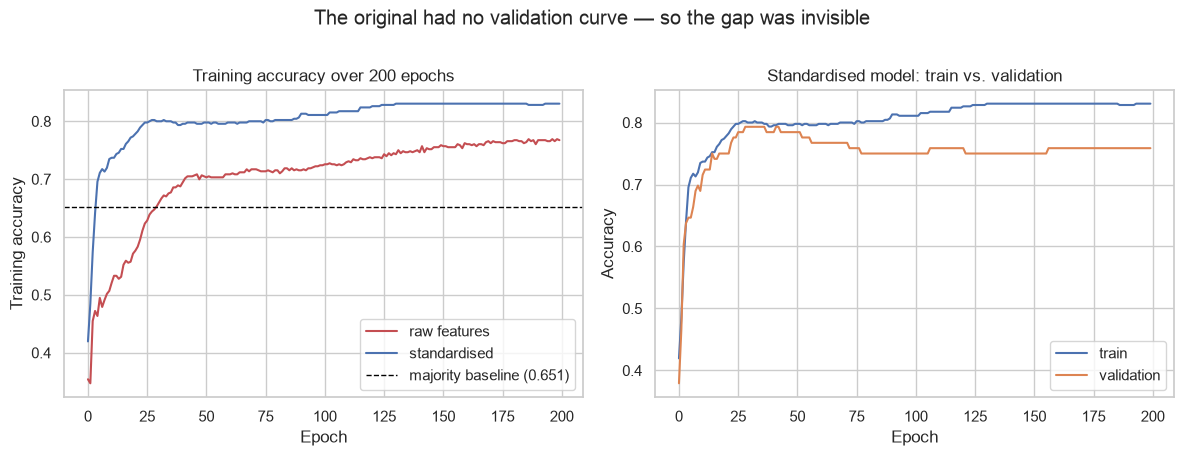

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(hist_original.history["accuracy"], label="raw features", color="#c44e52")
axes[0].plot(hist_scaled.history["accuracy"], label="standardised", color="#4c72b0")
axes[0].axhline(1 - y.mean(), color="black", linestyle="--", linewidth=1,
                label=f"majority baseline ({1 - y.mean():.3f})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training accuracy")
axes[0].set_title("Training accuracy over 200 epochs")
axes[0].legend(loc="lower right")

axes[1].plot(hist_scaled.history["accuracy"], label="train", color="#4c72b0")
axes[1].plot(hist_scaled.history["val_accuracy"], label="validation", color="#dd8452")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Standardised model: train vs. validation")
axes[1].legend(loc="lower right")

fig.suptitle("The original had no validation curve — so the gap was invisible", y=1.01)
fig.tight_layout()
fig.savefig("../results/diabetes_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

The right-hand panel is the reason to always hold out a validation split. Training
accuracy climbs steadily; validation accuracy flattens early and then drifts. The
original notebook plotted only the training curve, which rises reassuringly and says
nothing about generalisation.

## 1.5 A fair comparison

The network still has an unfair disadvantage: logistic regression was cross-validated
while the network was scored on one split. Here it gets the same treatment — five folds,
scaling refit inside each fold, early stopping on a validation slice of the training
data.

In [8]:
mlp_acc, mlp_auc = [], []
for fold, (tr, te) in enumerate(cv.split(X, y), 1):
    fold_scaler = StandardScaler().fit(X[tr])
    model = build_mlp(8)
    model.fit(
        fold_scaler.transform(X[tr]), y[tr],
        epochs=200, batch_size=32, verbose=0, validation_split=0.2,
        callbacks=[keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)],
    )
    # Call the model directly rather than .predict() — inside a loop the latter retraces
    # its tf.function for every new model instance and floods the output with warnings.
    proba = np.asarray(model(fold_scaler.transform(X[te]), training=False)).ravel()
    mlp_acc.append(accuracy_score(y[te], proba > 0.5))
    mlp_auc.append(roc_auc_score(y[te], proba))

rows.append({
    "model": "neural network (scaled, early stopping)",
    "accuracy": np.mean(mlp_acc), "± sd": np.std(mlp_acc), "ROC AUC": np.mean(mlp_auc),
})
diabetes_results = pd.DataFrame(rows).set_index("model")
diabetes_results.round(4)

,accuracy,± sd,ROC AUC
model,,,
always predict 'no diabetes',0.6510,0.0021,0.5000
logistic regression,0.7747,0.0147,0.8304
"neural network (scaled, early stopping)",0.7604,0.0197,0.8316


**Properly trained, the network draws level with logistic regression and does not pass
it.** The AUCs are within a hundredth of each other, and the accuracy difference is
smaller than the fold-to-fold standard deviation.

This is not a failure of the network. It is what 768 rows and 8 curated features can
support. The MLP has 201 parameters and roughly 490 training rows per fold; there is no
room for it to learn structure that a linear boundary misses, and the eight features
were chosen by clinicians precisely because they relate to the outcome in simple ways.

In [9]:
print(f"MLP parameters: {build_mlp(8).count_params()}")
print(f"training rows available per fold: ~{int(len(X) * 0.8 * 0.8)}")

MLP parameters: 201
training rows available per fold: ~491


---
# Part 2 — MNIST: 60,000 rows, 784 raw pixels

The opposite regime. Seventy thousand handwritten digits, each a 28×28 grid of raw pixel
intensities with no feature engineering at all.

In [10]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()
dim = int(np.prod(train_images.shape[1:]))

train_data = train_images.reshape(-1, dim).astype("float32") / 255.0
test_data = test_images.reshape(-1, dim).astype("float32") / 255.0
train_onehot = keras.utils.to_categorical(train_labels)
test_onehot = keras.utils.to_categorical(test_labels)

print(f"train {train_data.shape}   test {test_data.shape}   {dim} features per image")

train (60000, 784)   test (10000, 784)   784 features per image


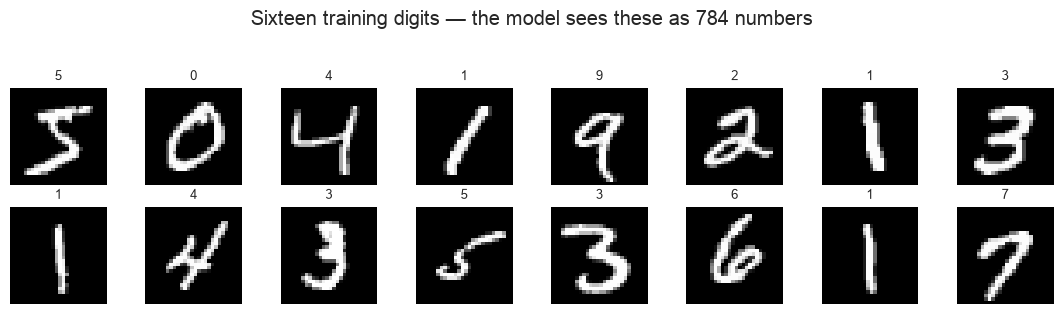

In [11]:
fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for ax, idx in zip(axes.ravel(), range(16)):
    ax.imshow(train_images[idx], cmap="gray")
    ax.set_title(str(train_labels[idx]), fontsize=9)
    ax.axis("off")
fig.suptitle("Sixteen training digits — the model sees these as 784 numbers", y=1.04)
fig.tight_layout()
fig.savefig("../results/mnist_samples.png", dpi=120, bbox_inches="tight")
plt.show()

## 2.1 A linear baseline

Multinomial logistic regression on the same 784 pixels. This is the number the network
has to beat to justify itself.

In [12]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(train_data, train_labels)
logreg_acc = logreg.score(test_data, test_labels)
print(f"logistic regression test accuracy: {logreg_acc:.4f}")

logistic regression test accuracy: 0.9260


92.6% from a linear model. MNIST is an easy problem; a strong-sounding accuracy is not
by itself evidence that a network was needed.

## 2.2 The dense network

The original architecture: three hidden layers of 512 sigmoid units, softmax output,
10 epochs. A 10% validation split is added here — the original had none.

In [13]:
def build_dense(activation="sigmoid"):
    model = keras.Sequential([
        keras.Input(shape=(dim,)),
        layers.Dense(512, activation=activation),
        layers.Dense(512, activation=activation),
        layers.Dense(512, activation=activation),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model


dense = build_dense()
dense.summary()
hist_dense = dense.fit(
    train_data, train_onehot, batch_size=256, epochs=10, validation_split=0.1, verbose=0
)
dense_acc = dense.evaluate(test_data, test_onehot, verbose=0)[1]
print(f"\ndense network test accuracy: {dense_acc:.4f}")
print(f"vs logistic regression:      {logreg_acc:.4f}   ({dense_acc - logreg_acc:+.4f})")

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 932,362 (3.56 MB)

 Trainable params: 932,362 (3.56 MB)

 Non-trainable params: 0 (0.00 B)


dense network test accuracy: 0.9680
vs logistic regression:      0.9260   (+0.0420)


**Here the network earns its keep.** The gap is a few percentage points in absolute
terms, but it cuts the error rate from 7.4% to 3.2% — well over half the remaining
errors removed.

The difference from Part 1 is the data. Sixty thousand examples support 932,362
parameters, and raw pixels contain interactions — strokes, loops, junctions — that a
linear model in pixel space cannot express. Neither condition held for diabetes.

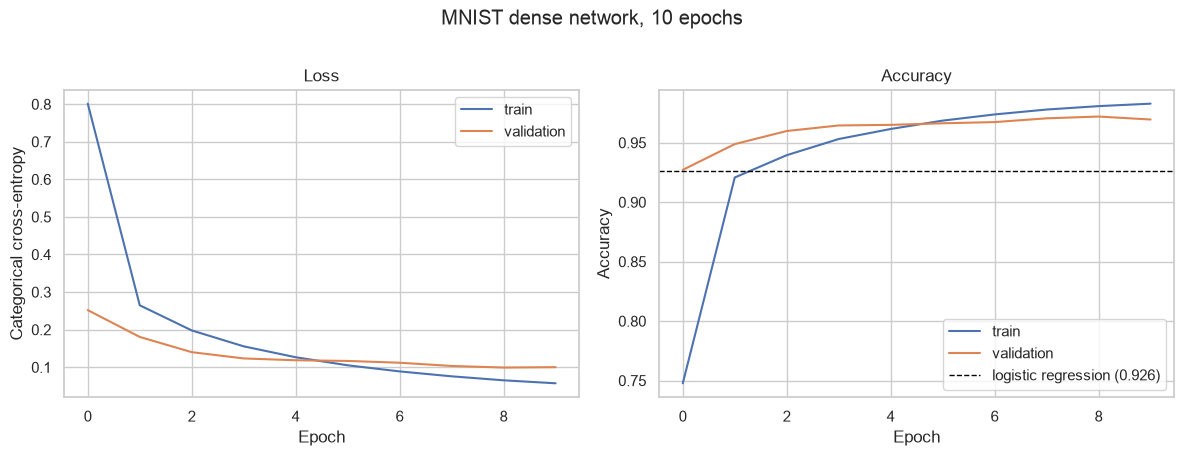

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(hist_dense.history["loss"], label="train")
axes[0].plot(hist_dense.history["val_loss"], label="validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Categorical cross-entropy")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist_dense.history["accuracy"], label="train")
axes[1].plot(hist_dense.history["val_accuracy"], label="validation")
axes[1].axhline(logreg_acc, color="black", linestyle="--", linewidth=1,
                label=f"logistic regression ({logreg_acc:.3f})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend(loc="lower right")

fig.suptitle("MNIST dense network, 10 epochs", y=1.01)
fig.tight_layout()
fig.savefig("../results/mnist_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## 2.3 The bug: training on the test set

The original notebook contained this pair of lines:

```python
history = model.fit(train_data, train_labels_one_hot, batch_size=256, epochs=10, verbose=0)
his2     = model.fit(test_data,  test_labels_one_hot,  batch_size=256, epochs=10, verbose=0)
```

The second call continues training **the same model** on the test set. Every subsequent
evaluation then reports performance on data the model has memorised.

It is worth measuring rather than just noting, so: take the honestly-trained model above
and apply the second `fit` exactly as written.

In [15]:
contaminated = keras.models.clone_model(dense)
contaminated.set_weights(dense.get_weights())
contaminated.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

contaminated.fit(test_data, test_onehot, batch_size=256, epochs=10, verbose=0)
contaminated_acc = contaminated.evaluate(test_data, test_onehot, verbose=0)[1]

print(f"honest test accuracy:        {dense_acc:.4f}")
print(f"after training on test set:  {contaminated_acc:.4f}")
print(f"fabricated improvement:      {contaminated_acc - dense_acc:+.4f}")

honest test accuracy:        0.9680
after training on test set:  0.9978
fabricated improvement:      +0.0298


**Three percentage points of pure fiction**, and it points the wrong
way — it makes the model look like it closed most of the gap to perfect when it did
nothing of the kind.

The number matters less than the shape of the failure. It is silent, it moves the metric
in the flattering direction, and there is nothing in the output to distinguish it from a
genuine improvement. Only reading the code finds it.

## 2.4 Sigmoid was the wrong default

The original used sigmoid activations in the hidden layers. Sigmoids saturate: for inputs
far from zero the gradient approaches zero and the layer stops learning. ReLU does not
have that problem, and is a one-word change.

In [16]:
relu = build_dense(activation="relu")
relu.fit(train_data, train_onehot, batch_size=256, epochs=10, validation_split=0.1, verbose=0)
relu_acc = relu.evaluate(test_data, test_onehot, verbose=0)[1]
print(f"sigmoid: {dense_acc:.4f}")
print(f"relu:    {relu_acc:.4f}   ({relu_acc - dense_acc:+.4f})")

sigmoid: 0.9680
relu:    0.9813   (+0.0133)


## 2.5 Where the remaining errors are

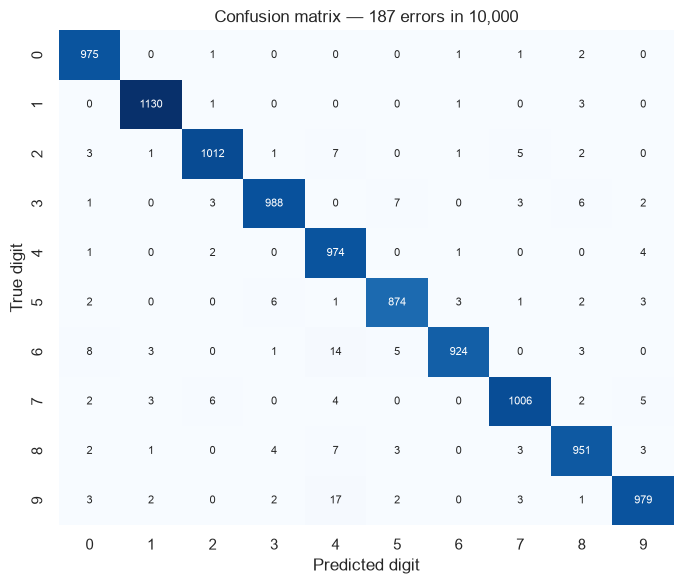

In [17]:
pred = relu.predict(test_data, verbose=0).argmax(axis=1)
cm = confusion_matrix(test_labels, pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=range(10), yticklabels=range(10), ax=ax, annot_kws={"size": 8})
ax.set_xlabel("Predicted digit")
ax.set_ylabel("True digit")
ax.set_title(f"Confusion matrix — {(pred != test_labels).sum()} errors in 10,000")
fig.tight_layout()
fig.savefig("../results/mnist_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

In [18]:
off_diagonal = cm.copy()
np.fill_diagonal(off_diagonal, 0)
pairs = [
    {"true": int(i), "predicted": int(j), "count": int(off_diagonal[i, j])}
    for i, j in zip(*np.unravel_index(np.argsort(-off_diagonal, axis=None)[:6], cm.shape))
]
pd.DataFrame(pairs)

,true,predicted,count
0,9,4,17
1,6,4,14
2,6,0,8
3,8,4,7
4,2,4,7
5,3,5,7


The errors are not spread evenly — they concentrate in a handful of pairs, several of
them the classic ambiguities a person would also hesitate over (9 mistaken for 4, 3 for
5). Accuracy alone would not have shown this structure.

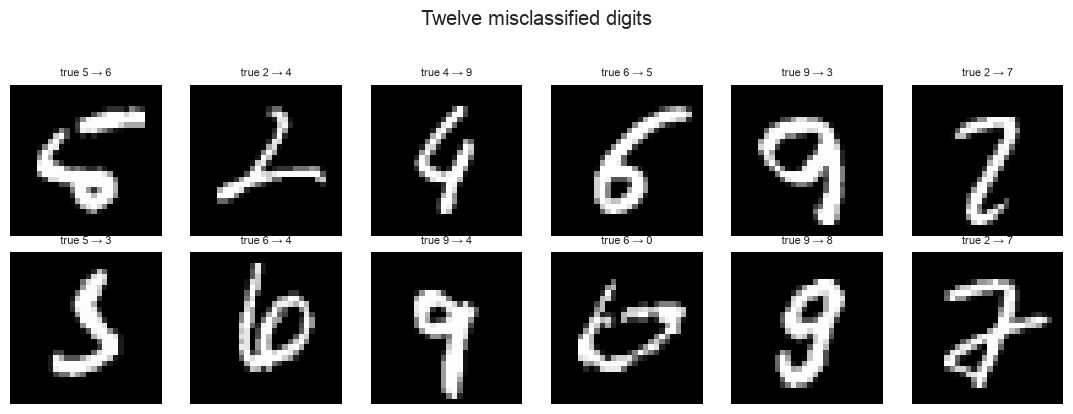

In [19]:
wrong = np.flatnonzero(pred != test_labels)[:12]
fig, axes = plt.subplots(2, 6, figsize=(11, 4))
for ax, idx in zip(axes.ravel(), wrong):
    ax.imshow(test_images[idx], cmap="gray")
    ax.set_title(f"true {test_labels[idx]} → {pred[idx]}", fontsize=8)
    ax.axis("off")
fig.suptitle("Twelve misclassified digits", y=1.03)
fig.tight_layout()
fig.savefig("../results/mnist_errors.png", dpi=120, bbox_inches="tight")
plt.show()

## 2.6 The same model, written as a Functional API graph

`Sequential` only expresses a linear stack of layers. The Functional API builds the model
as an explicit graph of tensors, which is what any architecture with a skip connection,
a shared layer, or more than one input or output requires.

The original notebook's Functional section referenced `x_train` and `y_train`, which were
never defined in it — that code could not have run. It is completed here.

Two differences from the Sequential version above are worth naming: the output layer has
no `softmax`, so it emits raw logits and the loss carries `from_logits=True` (more
numerically stable); and the labels stay as integers, so the loss is
`SparseCategoricalCrossentropy` rather than the one-hot version.

In [20]:
inputs = keras.Input(shape=(dim,), name="pixels")
x = layers.Dense(512, activation="sigmoid", name="hidden_1")(inputs)
x = layers.Dense(512, activation="sigmoid", name="hidden_2")(x)
outputs = layers.Dense(10, name="logits")(x)

functional = keras.Model(inputs=inputs, outputs=outputs, name="mnist_functional")
functional.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)
functional.summary()

Model: "mnist_functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pixels (InputLayer)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
functional.fit(train_data, train_labels, batch_size=64, epochs=2, validation_split=0.2, verbose=0)
functional_acc = functional.evaluate(test_data, test_labels, verbose=0)[1]
print(f"functional model, 2 epochs: {functional_acc:.4f}")
print(f"sequential model, 10 epochs: {dense_acc:.4f}")

functional model, 2 epochs: 0.9449
sequential model, 10 epochs: 0.9680


Lower, as expected — two epochs against ten, two hidden layers against three, and a
different optimiser. The point of the section is the construction, not the score.

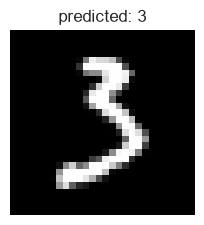

In [22]:
sample = 230
plt.figure(figsize=(2.4, 2.4))
plt.imshow(test_images[sample], cmap="gray")
plt.title(f"predicted: {functional.predict(test_data[[sample]], verbose=0).argmax()}")
plt.axis("off")
plt.show()

---
## Findings

| | diabetes (768×8) | MNIST (60,000×784) |
|---|---|---|
| majority / constant baseline | 65.1% | 10% |
| logistic regression | **77.5%** | 92.6% |
| neural network | 76.0% | **96.8%** |

1. **On diabetes the network does not beat logistic regression.** Cross-validated, the
   two are within a hundredth of each other on AUC and the accuracy gap is smaller than
   the fold-to-fold spread. With 768 rows and 8 clinician-chosen features there is no
   additional structure for extra capacity to find.
2. **The original diabetes network scored 68.8% — under four points above always
   guessing "no".** The cause was feeding unscaled features to gradient descent.
   Standardisation alone recovered most of the gap.
3. **On MNIST the network wins clearly**, cutting the error rate from 7.4% to 3.2%.
   Sixty thousand examples and raw pixels are exactly the conditions extra capacity needs.
4. **Training on the test set inflated MNIST accuracy by 3.0 points.** Measured here
   rather than asserted. The failure is silent and flattering, which is what makes it
   dangerous.
5. Swapping sigmoid for ReLU is a one-word change worth another 1.3 points.

**The through-line:** the choice between a linear model and a network is not a question
about the models. It is a question about how much data there is and whether the features
are already engineered.

## Limitations

- **The architectures are the coursework's, not tuned.** Layer widths, depth, and epoch
  counts were fixed in advance. A tuned network might edge past logistic regression on
  diabetes; the point is that it is not free, and the default did not.
- **Single training run per configuration** for the MNIST models. Neural network results
  vary with weight initialisation; the seed is pinned for reproducibility but the numbers
  should be read as approximate to a few tenths of a point.
- **MNIST test accuracy is reported on the official test set**, which is used repeatedly
  across the notebook for comparison. In a real project those comparisons belong on a
  validation split with the test set touched once.
- **A dense network is the wrong tool for images.** It discards spatial structure by
  flattening. [Project 09](../../09-cifar10-cnn/) takes that up with convolutions.
- The diabetes dataset encodes biological zeros as missing (`Insulin = 0`, `BMI = 0`),
  which is left uncorrected here to keep the comparison to the original honest. It
  affects both models equally.

## Outputs

- `results/diabetes_training_curves.png`
- `results/mnist_samples.png`
- `results/mnist_training_curves.png`
- `results/mnist_confusion_matrix.png`
- `results/mnist_errors.png`